# Cheek Structure Analysis Pipeline (with LLM)

This notebook uses the MediaPipe Tasks API to extract facial landmarks and uses the Groq LLM API to generate a personalized aesthetic report based on the geometric data.

In [1]:
!pip install mediapipe opencv-python matplotlib numpy requests ipywidgets Pillow groq python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import io
import json
import ipywidgets as widgets
from IPython.display import display
from PIL import Image, ImageOps
from groq import Groq

mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

## 1. Load Groq API Key
Automatically loads your API key from the `.env` file.

In [3]:
try:
    with open('.env', 'r') as f:
        API_KEY = f.read().strip()
    print("✅ API Key loaded from .env")
except FileNotFoundError:
    API_KEY = "YOUR_GROQ_API_KEY_HERE"
    print("⚠️ No .env file found. Using default placeholder.")

✅ API Key loaded from .env


## 2. Upload an Image

In [4]:
import tkinter as tk
from tkinter import filedialog
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
import io

# Open a native OS file dialog
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
file_path = filedialog.askopenfilename(
    title="Select a Face Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")]
)
root.destroy()

if file_path:
    print(f"Loading image from: {file_path}")
    pil_image = Image.open(file_path)
    # Apply EXIF rotation to fix any sideways images from phones
    pil_image = ImageOps.exif_transpose(pil_image).convert('RGB')
    image_rgb = np.ascontiguousarray(np.array(pil_image))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image_rgb)
    plt.title('Selected Image')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No file selected!")
    image_rgb = None


FileUpload(value=(), accept='image/*', description='Upload')

## 3. Initialize Image & Model

In [11]:
if image_rgb is not None:
    model_path = 'face_landmarker.task'
    if not os.path.exists(model_path):
        url = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
        response = requests.get(url)
        with open(model_path, 'wb') as f:
            f.write(response.content)

    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(base_options=base_options,
                                           output_face_blendshapes=False,
                                           output_facial_transformation_matrixes=False,
                                           num_faces=1)
    detector = vision.FaceLandmarker.create_from_options(options)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if detection_result.face_landmarks:
        face_landmarks = detection_result.face_landmarks[0]
        print("✅ Face landmarks detected!")
    else:
        print("❌ No face detected.")
        face_landmarks = None
else:
    face_landmarks = None

✅ Face landmarks detected!


## 4. Cheek Geometric Data Extraction

In [12]:
def analyze_cheeks(landmarks, w, h):
    def get_pt(idx):
        return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        
    right_cheek = get_pt(234)
    left_cheek = get_pt(454)
    right_jaw = get_pt(132)
    left_jaw = get_pt(361)
    chin = get_pt(152)
    top_head = get_pt(10)
    right_eye = get_pt(33)
    left_eye = get_pt(263)
    
    cheek_width = np.linalg.norm(right_cheek - left_cheek)
    jaw_width = np.linalg.norm(right_jaw - left_jaw)
    lateral_projection_ratio = cheek_width / jaw_width
    
    face_height = chin[1] - top_head[1]
    avg_eye_y = (right_eye[1] + left_eye[1]) / 2.0
    avg_cheek_y = (right_cheek[1] + left_cheek[1]) / 2.0
    cheek_height_ratio = (avg_cheek_y - avg_eye_y) / face_height
    
    return lateral_projection_ratio, cheek_height_ratio, cheek_width, jaw_width

if face_landmarks:
    h, w, _ = image_rgb.shape
    lateral_ratio, cheek_height_ratio, cheek_w, jaw_w = analyze_cheeks(face_landmarks, w, h)
    print(f"Lateral Projection Ratio (Cheek/Jaw Width): {lateral_ratio:.3f}")
    print(f"Cheek Height Ratio (Lower is Higher): {cheek_height_ratio:.3f}")

Lateral Projection Ratio (Cheek/Jaw Width): 1.041
Cheek Height Ratio (Lower is Higher): 0.133


## 5. Dynamic LLM Text Generation (Groq API)

In [13]:
main_text = "Error generating text."
summary_text = "Error generating summary."

if face_landmarks:
    if API_KEY == "YOUR_GROQ_API_KEY_HERE" or not API_KEY:
        print("⚠️ Please provide a valid Groq API Key!")
    else:
        try:
            client = Groq(api_key=API_KEY)
            
            prompt = f"""
            You are an expert facial aesthetician. I am analyzing a client's cheek structure based on geometric data extracted via AI.
            
            Data:
            - Lateral Projection Ratio (Cheekbone width / Jaw width): {lateral_ratio:.3f} (Values > 1.15 mean the cheekbones are laterally projecting and wide relative to the jaw).
            - Cheek Height Ratio: {cheek_height_ratio:.3f} (Values < 0.12 mean the cheekbones sit very high on the face, close to the eyes).
            
            Task:
            Generate an aesthetic report for this subject. 
            Write a personalized "main_text" paragraph describing their cheek structure and offering minor aesthetic suggestions (e.g., if they are highly structured, suggest skin tightening; if they lack structure, suggest contouring/midface volume).
            Write a short 1-sentence "summary_text" highlighting the main takeaway.
            
            Respond ONLY with a valid JSON object matching this schema:
            {{
                "main_text": "paragraph here",
                "summary_text": "summary here"
            }}
            """
            
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a facial aesthetician API that outputs ONLY valid JSON."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                model="llama-3.1-8b-instant",
                response_format={"type": "json_object"},
            )
            
            output = json.loads(chat_completion.choices[0].message.content)
            main_text = output.get("main_text", "")
            summary_text = output.get("summary_text", "")
            
            print("✅ Dynamic text generated successfully by Groq API!")
        except Exception as e:
            print(f"❌ Error communicating with Groq API: {e}")

❌ Error communicating with Groq API: Connection error.


## 6. Dynamic Visual Overlay Mapping

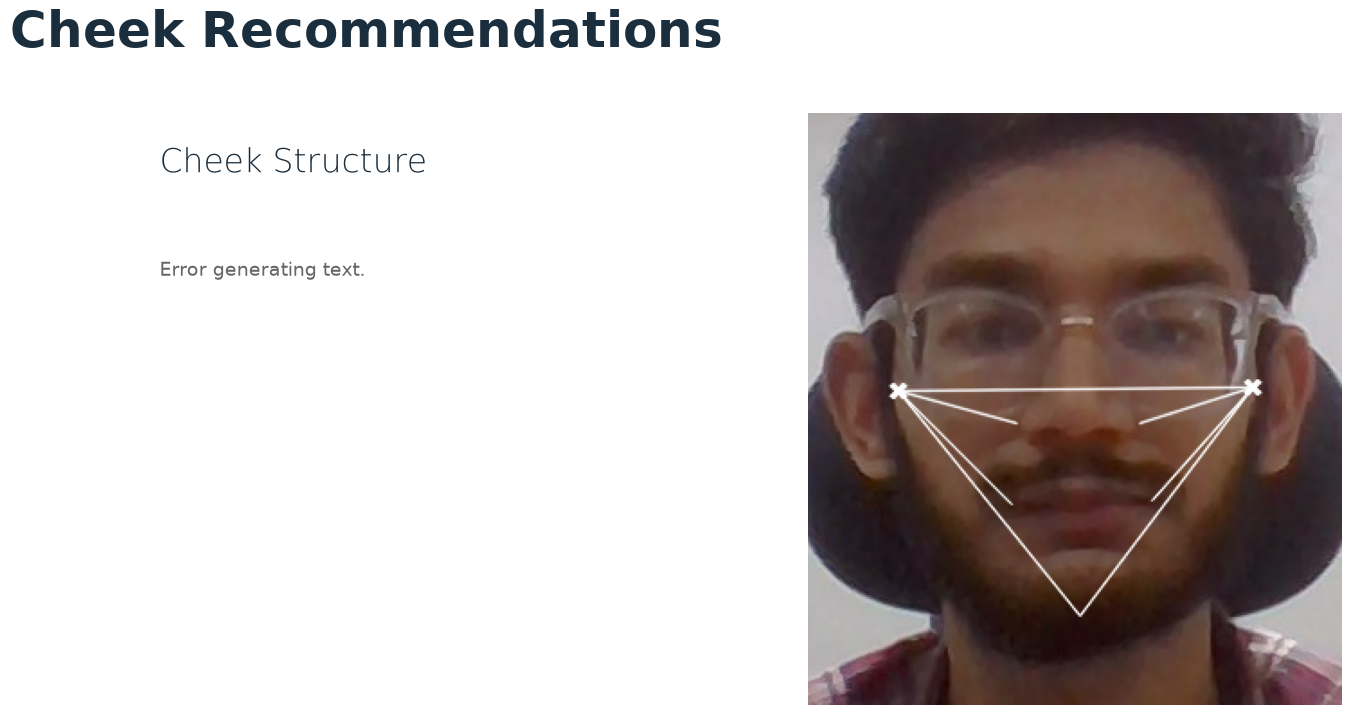

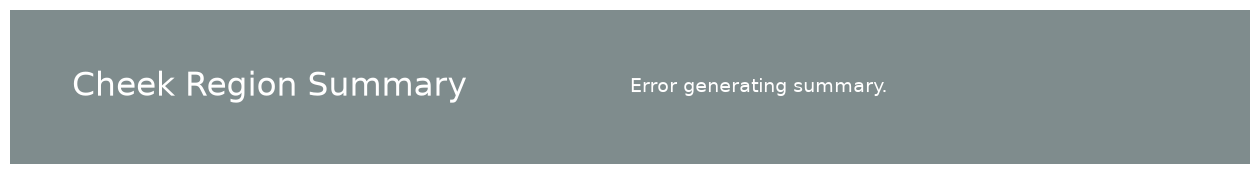

In [14]:
if face_landmarks:
    annotated_image = image_rgb.copy()
    
    def get_pt(idx):
        return (int(face_landmarks[idx].x * w), int(face_landmarks[idx].y * h))

    # Extract key points for contour vectors
    r_zygion = get_pt(234)  # Right outer cheekbone
    r_nose = get_pt(129)    # Right outer nose wing
    r_mouth = get_pt(61)    # Right corner of mouth
    
    l_zygion = get_pt(454)  # Left outer cheekbone
    l_nose = get_pt(358)    # Left outer nose wing
    l_mouth = get_pt(291)   # Left corner of mouth
    
    chin = get_pt(152)
    top_head = get_pt(10)

    # 1. Draw crisp white contour vectors with ANTI-ALIASING for perfectly smooth lines
    line_color = (255, 255, 255)
    thickness = 1
    
    cv2.line(annotated_image, r_zygion, r_nose, line_color, thickness, cv2.LINE_AA)
    cv2.line(annotated_image, r_zygion, r_mouth, line_color, thickness, cv2.LINE_AA)
    cv2.line(annotated_image, r_zygion, chin, line_color, thickness, cv2.LINE_AA)
    
    cv2.line(annotated_image, l_zygion, l_nose, line_color, thickness, cv2.LINE_AA)
    cv2.line(annotated_image, l_zygion, l_mouth, line_color, thickness, cv2.LINE_AA)
    cv2.line(annotated_image, l_zygion, chin, line_color, thickness, cv2.LINE_AA)

    # 2. Subtle horizontal width line (connecting the cheekbones)
    cv2.line(annotated_image, r_zygion, l_zygion, line_color, thickness, cv2.LINE_AA)
    
    # 3. Add modern structural markers on the lateral cheekbones (Zygion)
    # Reduced markerSize from 10 to 6 for a more subtle, delicate aesthetic
    cv2.drawMarker(annotated_image, r_zygion, line_color, markerType=cv2.MARKER_TILTED_CROSS, markerSize=6, thickness=2, line_type=cv2.LINE_AA)
    cv2.drawMarker(annotated_image, l_zygion, line_color, markerType=cv2.MARKER_TILTED_CROSS, markerSize=6, thickness=2, line_type=cv2.LINE_AA)
    
    # Top/Bottom boundary extraction for cropping
    chin = get_pt(152)
    top_head = get_pt(10)
    
    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_facecolor('#FFFFFF')
    
    plt.suptitle("Cheek Recommendations", fontsize=36, fontweight='bold', ha='left', x=0.05, y=0.98, color='#1B2E3D')
    
    ax_text = plt.subplot2grid((1, 2), (0, 0))
    ax_text.axis('off')
    ax_text.text(0.05, 0.9, "Cheek Structure", fontsize=24, fontweight='light', color='#1B2E3D')
    
    import textwrap
    wrapped_main_text = textwrap.fill(main_text, width=50)
    ax_text.text(0.05, 0.75, wrapped_main_text, fontsize=14, color='#666666', va='top')
    
    ax_img = plt.subplot2grid((1, 2), (0, 1))
    y_start = max(0, int(top_head[1]) - 50)
    y_end = min(h, int(chin[1]) + 50)
    x_start = max(0, int(r_zygion[0]) - 50)
    x_end = min(w, int(l_zygion[0]) + 50)
    
    cropped_annotated = annotated_image[y_start:y_end, x_start:x_end]
    ax_img.imshow(cropped_annotated)
    ax_img.axis('off')
    
    plt.subplots_adjust(top=0.85, wspace=0.1)
    plt.show()
    
    fig2 = plt.figure(figsize=(16, 2))
    ax_strip = fig2.add_subplot(111)
    ax_strip.axis('off')
    rect = plt.Rectangle((0, 0), 1, 1, facecolor='#7F8C8D', transform=ax_strip.transAxes)
    ax_strip.add_patch(rect)
    
    ax_strip.text(0.05, 0.5, "Cheek Region Summary", fontsize=24, color='white', va='center', transform=ax_strip.transAxes)
    wrapped_summary = textwrap.fill(summary_text, width=60)
    ax_strip.text(0.5, 0.5, wrapped_summary, fontsize=14, color='white', va='center', transform=ax_strip.transAxes)
    
    plt.show()